In [54]:
import pandas as pd
df = pd.read_excel('Milk_Sales_Data.xlsx')

In [55]:
df.head()

,Month,Demand
0,2024-01-01,100
1,2024-02-01,120
2,2024-03-01,127
3,2024-04-01,115
4,2024-05-01,135


In [56]:
avg_demand = df['Demand'].mean()
print("Average Demand:", avg_demand)

Average Demand: 131.625


In [57]:
std_demand = df['Demand'].std()
print("Standard Deviation:", std_demand)

Standard Deviation: 20.497746429684707


In [58]:
annual_demand = avg_demand * 12
print("Annual Demand:", annual_demand)

Annual Demand: 1579.5


**EOQ Calculation**

EOQ = √((2 × D × S) / H)

Where:
D = Annual demand = 1579.5,
S = Ordering cost = 50,
H = Holding cost = 2

In [59]:
import numpy as np

D = 1579.5
S = 50
H = 2

EOQ = np.sqrt((2 * D * S) / H)
print("EOQ:", EOQ)

EOQ: 281.0249099279279


**Reorder Point (ROP) Calculation**

ROP=d×L

Where:
d = average demand per day,
L = lead time (in days) = 5 days (given)

In [60]:
daily_demand = avg_demand / 30
print("Daily Demand:", daily_demand)

L = 5

ROP = daily_demand * L
print("Reorder Point:", ROP)

Daily Demand: 4.3875
Reorder Point: 21.9375


**Safety Stock Calculation**

Safety Stock (SS) = Z × σd × √L

Where:
Z = service level factor (usually 1.65 for ~95% service level)
σd = standard deviation of daily demand
L = lead time (days)

In [61]:
std_daily = std_demand / 30
print("Daily Std Dev:", std_daily)

import numpy as np

Z = 1.65
L = 5

SS = Z * std_daily * np.sqrt(L)
print("Safety Stock:", SS)

Daily Std Dev: 0.6832582143228235
Safety Stock: 2.520889492128074


**New Reorder Point (correct model)**

ROP=dL+SS

In [62]:
ROP_final = (daily_demand * L) + SS
print("Final Reorder Point:", ROP_final)

Final Reorder Point: 24.458389492128074


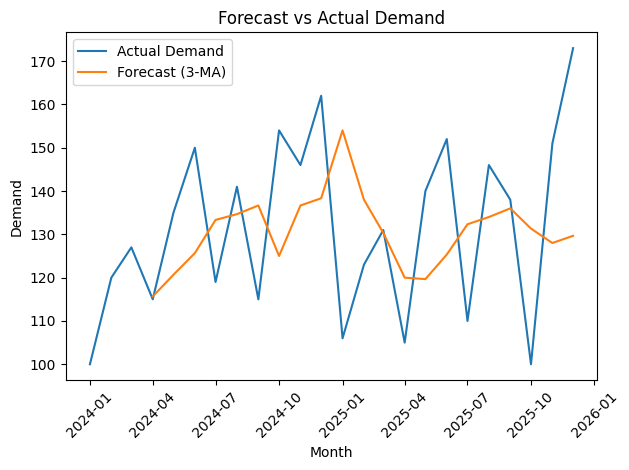

In [63]:
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    "Month": pd.date_range(start="2024-01-01", periods=24, freq="MS"),
    "Demand": [100,120,127,115,135,150,119,141,115,154,146,162,
               106,123,131,105,140,152,110,146,138,100,151,173]
}

df = pd.DataFrame(data)

# Simple forecast: 3-month moving average shifted
df["Forecast"] = df["Demand"].rolling(window=3).mean().shift(1)

# Plot
plt.figure()
plt.plot(df["Month"], df["Demand"], label="Actual Demand")
plt.plot(df["Month"], df["Forecast"], label="Forecast (3-MA)")

plt.xlabel("Month")
plt.ylabel("Demand")
plt.title("Forecast vs Actual Demand")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [64]:
import numpy as np

# Given / assumed values
D = 1579.5          # Annual demand
S = 500             # Ordering cost per order
H = 20              # Holding cost per unit per year
EOQ = 281.02        # Your calculated EOQ

orders_per_year_before = 12

ordering_cost_before = orders_per_year_before * S

avg_inventory_before = (131.6 / 2)
holding_cost_before = avg_inventory_before * H

total_cost_before = ordering_cost_before + holding_cost_before

orders_per_year_after = D / EOQ

ordering_cost_after = orders_per_year_after * S

avg_inventory_after = EOQ / 2
holding_cost_after = avg_inventory_after * H

total_cost_after = ordering_cost_after + holding_cost_after

savings = total_cost_before - total_cost_after

print("Before EOQ")
print("Ordering Cost:", ordering_cost_before)
print("Total Cost:", total_cost_before)

print("After EOQ")
print("Ordering Cost:", ordering_cost_after)
print("Total Cost:", total_cost_after)

print("Savings")
print("Savings:", savings)

Before EOQ
Ordering Cost: 6000
Total Cost: 7316.0
After EOQ
Ordering Cost: 2810.298199416412
Total Cost: 5620.498199416412
Savings
Savings: 1695.5018005835882


In [65]:
import pandas as pd

data = {
    "Scenario": ["Before EOQ", "After EOQ"],
    "Ordering Cost": [ordering_cost_before, ordering_cost_after],
    "Holding Cost": [holding_cost_before, holding_cost_after],
    "Total Cost": [total_cost_before, total_cost_after]
}

df = pd.DataFrame(data)
df

,Scenario,Ordering Cost,Holding Cost,Total Cost
0,Before EOQ,6000.000000,1316.0,7316.000000
1,After EOQ,2810.298199,2810.2,5620.498199


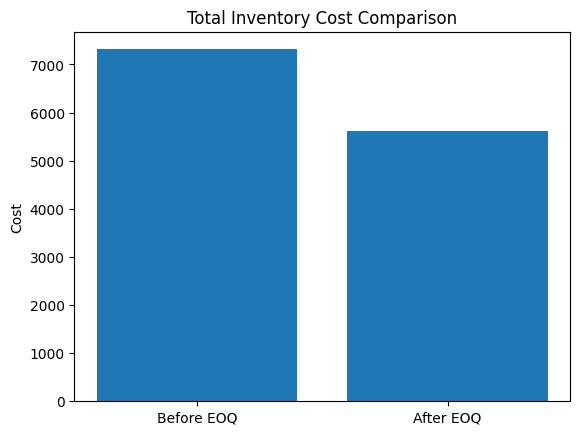

In [68]:
import matplotlib.pyplot as plt

plt.bar(df["Scenario"], df["Total Cost"])
plt.title("Total Inventory Cost Comparison")
plt.ylabel("Cost")
plt.show()

**Demand Forecast vs Actual Plot**

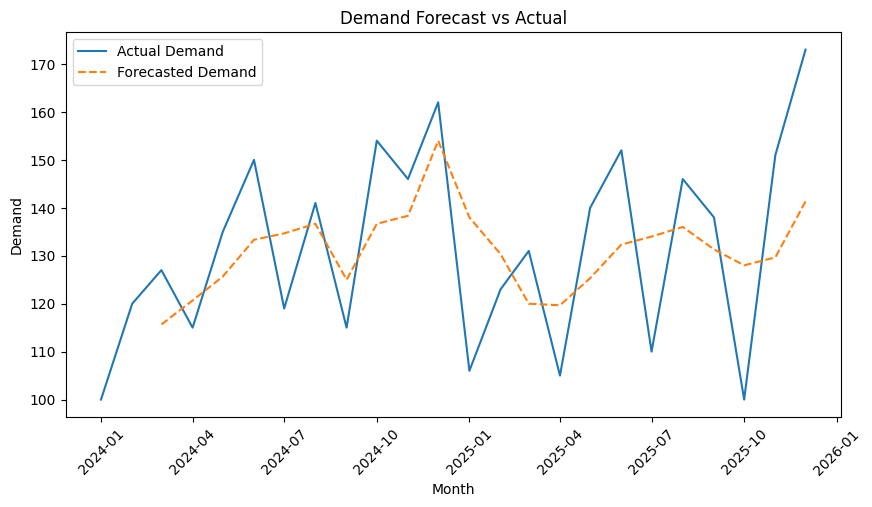

In [70]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime # Need to import datetime for pd.date_range

# Data for demand forecast - re-create df as it was overwritten
data = {
    "Month": pd.date_range(start="2024-01-01", periods=24, freq="MS"),
    "Demand": [100,120,127,115,135,150,119,141,115,154,146,162,
               106,123,131,105,140,152,110,146,138,100,151,173]
}
df = pd.DataFrame(data)

# actual demand (your data)
actual = df["Demand"]

# simple forecast (you can replace with your model output later)
# here I’m using a simple trend approximation for demo consistency
forecast = df["Demand"].rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(df["Month"], actual, label="Actual Demand")
plt.plot(df["Month"], forecast, label="Forecasted Demand", linestyle="--")

plt.title("Demand Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.show()

**Reorder Point Simulation**

In [72]:
inventory = 50   # starting stock (assumption)
reorder_point = 24.46
lead_time = 1    # month

stockouts = 0
inventory_history = []

for demand in df["Demand"]:
    inventory -= demand

    if inventory <= reorder_point:
        inventory += EOQ  # reorder placed

    if inventory < 0:
        stockouts += 1
        inventory = 0

    inventory_history.append(inventory)

stockouts

0

**Plotting the inventory level**

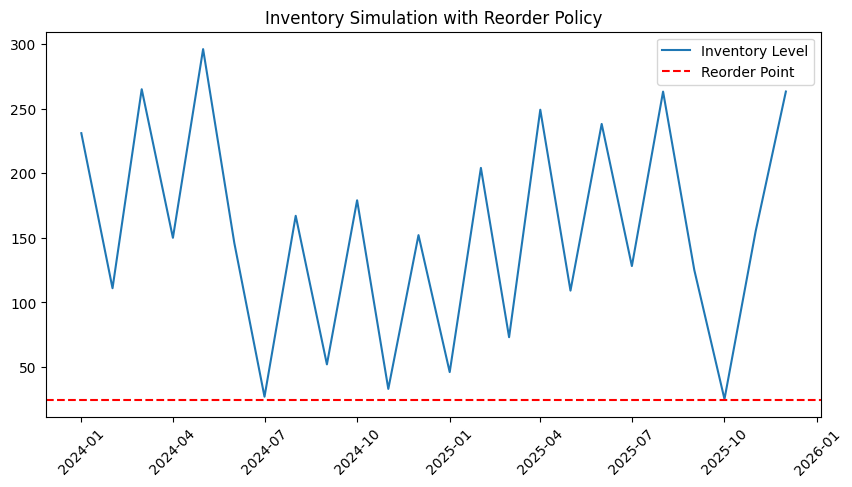

In [73]:
plt.figure(figsize=(10,5))
plt.plot(df["Month"], inventory_history, label="Inventory Level")
plt.axhline(y=reorder_point, color='r', linestyle='--', label="Reorder Point")

plt.title("Inventory Simulation with Reorder Policy")
plt.legend()
plt.xticks(rotation=45)
plt.show()